# Regresión Logística — Base de datos `Default`

**Parte práctica: Introducción a la Econometría — Modelos de Regresión**

En este notebook aplicamos el modelo de **regresión logística** sobre la base
`Default` (paquete `ISLR`), que tiene 10,000 datos de clientes de
tarjetas de crédito. La variable respuesta es binaria: si el cliente incurrió
o no en impago (*default*).

Cargamos los datos directamente desde el repositorio
[Rdatasets](https://vincentarelbundock.github.io/Rdatasets/).


## 1. Datos

In [24]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score

# Cargamos la base Default (paquete ISLR) vía Rdatasets
default = sm.datasets.get_rdataset("Default", "ISLR").data
default.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


Creamos versiones numéricas (0-1) de las variables categóricas, necesarias
para ajustar el modelo:

- `default_bin`: 1 si el cliente incumplió, 0 si no.
- `student_bin`: 1 si el cliente es estudiante, 0 si no.


In [25]:
default["default_bin"] = (default["default"] == "Yes").astype(int)
default["student_bin"] = (default["student"] == "Yes").astype(int)

print("Proporción de incumplimiento en la muestra:")
print(default["default_bin"].value_counts(normalize=True))

Proporción de incumplimiento en la muestra:
default_bin
0    0.9667
1    0.0333
Name: proportion, dtype: float64


En clasificación y en general, cuando se ajustan modelos, es buena práctica dividir la
muestra en **entrenamiento**  y **prueba**. Usamos `stratify` para conservar la proporción de incumplimiento
en ambos conjuntos. 


**Entrar en default**: dejar de pagar una deuda. Abajo un gráfico que contiene en el eje X, el saldo de deuda que tiene el cliente contra default_bin (eje Y, que solo puede ser 0 o 1).

In [26]:
train, test = train_test_split(
    default, test_size=0.3, random_state=123, stratify=default["default_bin"]
)
print(f"Entrenamiento: {train.shape[0]} obs. | Prueba: {test.shape[0]} obs.")

Entrenamiento: 7000 obs. | Prueba: 3000 obs.


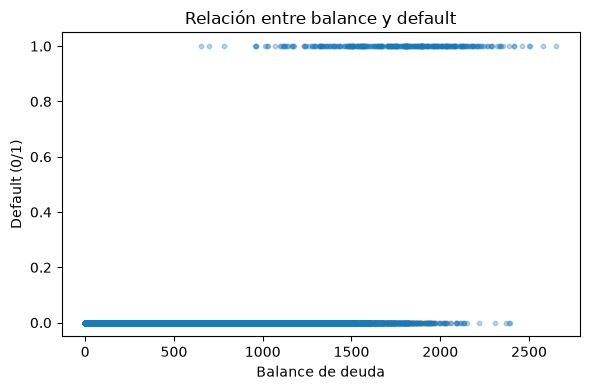

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(default["balance"], default["default_bin"], alpha=0.3, s=10)
ax.set_xlabel("Balance de deuda")
ax.set_ylabel("Default (0/1)")
ax.set_title("Relación entre balance y default")
plt.tight_layout()
plt.show()

## 2. Ajuste del modelo: Regresión logística simple

Empecemos con un modelo simple posible: predecir el incumplimiento
(`default`) usando únicamente el `balance` de deuda del cliente.

$$
\text{logit}(\theta_i) = \beta_0 + \beta_1 \cdot \text{balance}_i
$$


In [28]:
mod_simple = smf.glm(
    "default_bin ~ balance", data=train, family=sm.families.Binomial()
).fit()

#glm: general linear models 

print(mod_simple.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            default_bin   No. Observations:                 7000
Model:                            GLM   Df Residuals:                     6998
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -555.51
Date:                Thu, 17 Sep 2026   Deviance:                       1111.0
Time:                        13:23:03   Pearson chi2:                 3.21e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1248
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.7134      0.435    -24.603      0.0

Vemos que la variable es significativa (Pvalue<0.05), quiere decir que aporta a predecir si entrará en "Default" o no. 

In [29]:
print("Coeficientes:\n", mod_simple.params)

print(mod_simple.pvalues)

Coeficientes:
 Intercept   -10.713429
balance       0.005524
dtype: float64
Intercept    1.166546e-133
balance       8.613674e-97
dtype: float64


Interpretamos `balance` en términos de razón de probabilidades (odds ratio):

In [30]:
or_balance = np.exp(mod_simple.params["balance"])
print(f"OR(balance) = {or_balance:.4f}")
print(f"Por cada unidad adicional de balance, las chances de incumplir "
      f"se multiplican por {or_balance:.4f} "
      f"({(or_balance - 1) * 100:.2f} % de cambio).")

OR(balance) = 1.0055
Por cada unidad adicional de balance, las chances de incumplir se multiplican por 1.0055 (0.55 % de cambio).


### 4. Métricas de evaluación

Calculamos las métricas descritas en la charla: matriz de confusión, TCC,
curva ROC y AUC.


In [31]:
test = test.copy()
test["prob_simple"] = mod_simple.predict(test)
test["pred_simple"] = (test["prob_simple"] > 0.5).astype(int)

cm_simple = confusion_matrix(test["default_bin"], test["pred_simple"])
print("Matriz de confusión (modelo simple):")
print(pd.DataFrame(cm_simple,
                    index=["Real: No", "Real: Sí"],
                    columns=["Predicho: No", "Predicho: Sí"]))

Matriz de confusión (modelo simple):
          Predicho: No  Predicho: Sí
Real: No          2891             9
Real: Sí            72            28


In [32]:
tcc_simple = accuracy_score(test["default_bin"], test["pred_simple"])
auc_simple = roc_auc_score(test["default_bin"], test["prob_simple"])

print(f"TCC (modelo simple): {tcc_simple:.4f}")
print(f"AUC (modelo simple): {auc_simple:.4f}")

TCC (modelo simple): 0.9730
AUC (modelo simple): 0.9386


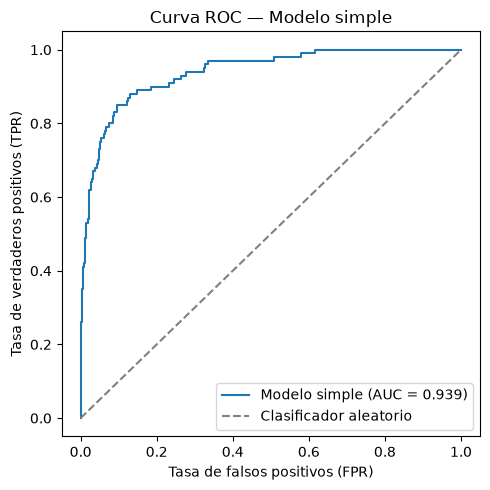

In [33]:
fpr, tpr, _ = roc_curve(test["default_bin"], test["prob_simple"])

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"Modelo simple (AUC = {auc_simple:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC — Modelo simple")
plt.legend()
plt.tight_layout()
plt.show()

### 4.1 Gráfico

 Los puntos representan las observaciones reales (0 = no incumplió, 1 = incumplió), mientras que la curva roja corresponde a la probabilidad de default estimada por el modelo para cada nivel de balance. La línea punteada en 0.5 marca el umbral de clasificación usado: los clientes cuya curva ajustada supera ese valor son clasificados como default. 

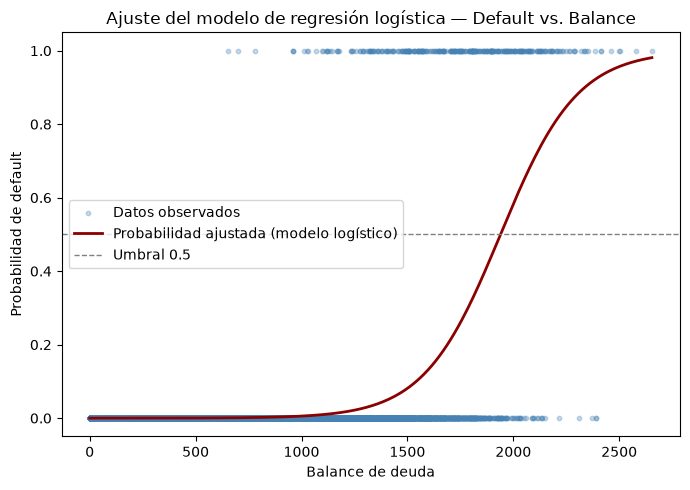

In [34]:

balance_range = pd.DataFrame({"balance": np.linspace(default["balance"].min(),
                                                       default["balance"].max(), 300)})
balance_range["prob_pred"] = mod_simple.predict(balance_range)

fig, ax = plt.subplots(figsize=(7, 5))

# Datos reales
ax.scatter(default["balance"], default["default_bin"],
           alpha=0.3, s=10, color="steelblue", label="Datos observados")

# Curva
ax.plot(balance_range["balance"], balance_range["prob_pred"],
        color="darkred", linewidth=2, label="Probabilidad ajustada (modelo logístico)")

ax.axhline(0.5, linestyle="--", color="gray", linewidth=1, label="Umbral 0.5")

ax.set_xlabel("Balance de deuda")
ax.set_ylabel("Probabilidad de default")
ax.set_title("Ajuste del modelo de regresión logística — Default vs. Balance")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Siguiente modelo: Regresión logística múltiple

Añadimos más predictoras económicas: `income` (ingreso) y `student` (si es
estudiante), para ver si mejoran la capacidad predictiva del modelo.

$$
\text{logit}(\theta_i) = \beta_0 + \beta_1 \cdot \text{balance}_i +
\beta_2 \cdot \text{income}_i + \beta_3 \cdot \text{student}_i
$$


In [35]:
mod_mult = smf.glm(
    "default_bin ~ balance + income + student_bin",
    data=train, family=sm.families.Binomial()
).fit()

print(mod_mult.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            default_bin   No. Observations:                 7000
Model:                            GLM   Df Residuals:                     6996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -544.28
Date:                Thu, 17 Sep 2026   Deviance:                       1088.6
Time:                        13:23:04   Pearson chi2:                 3.24e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1276
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -11.0223      0.594    -18.561      

### Pruebas de hipótesis (modelo múltiple)

In [36]:
print(mod_mult.pvalues)

# Odds ratios de todas las variables
print("\nOdds ratios:")
print(np.exp(mod_mult.params))

Intercept      6.586775e-77
balance        1.478800e-94
income         6.668313e-01
student_bin    1.033165e-02
dtype: float64

Odds ratios:
Intercept      0.000016
balance        1.005830
income         1.000004
student_bin    0.485081
dtype: float64


### Métricas de evaluación (modelo múltiple)

In [37]:
test["prob_mult"] = mod_mult.predict(test)
test["pred_mult"] = (test["prob_mult"] > 0.5).astype(int)

cm_mult = confusion_matrix(test["default_bin"], test["pred_mult"])
print("Matriz de confusión (modelo múltiple):")
print(pd.DataFrame(cm_mult,
                    index=["Real: No", "Real: Sí"],
                    columns=["Predicho: No", "Predicho: Sí"]))

tcc_mult = accuracy_score(test["default_bin"], test["pred_mult"])
auc_mult = roc_auc_score(test["default_bin"], test["prob_mult"])

print(f"\nTCC (modelo múltiple): {tcc_mult:.4f}")
print(f"AUC (modelo múltiple): {auc_mult:.4f}")

Matriz de confusión (modelo múltiple):
          Predicho: No  Predicho: Sí
Real: No          2892             8
Real: Sí            66            34

TCC (modelo múltiple): 0.9753
AUC (modelo múltiple): 0.9396


## 6. Comparación de modelos

Comparamos ambos modelos usando TCC y AUC.


In [38]:
comparacion = pd.DataFrame({
    "Modelo": ["Simple (balance)", "Múltiple (balance + income + student)"],
    "TCC": [tcc_simple, tcc_mult],
    "AUC": [auc_simple, auc_mult],
})
comparacion

,Modelo,TCC,AUC
0,Simple (balance),0.973000,0.938638
1,Múltiple (balance + income + student),0.975333,0.939579


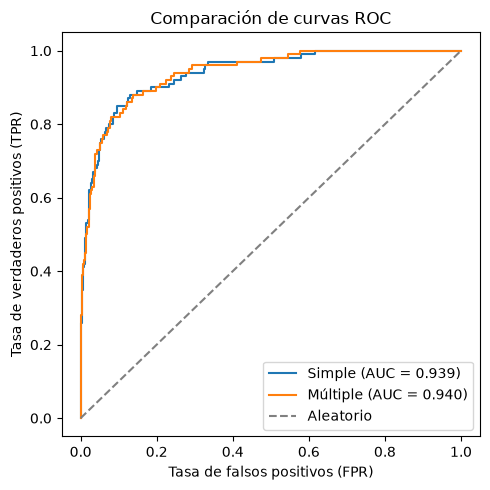

In [39]:
fpr_m, tpr_m, _ = roc_curve(test["default_bin"], test["prob_mult"])

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"Simple (AUC = {auc_simple:.3f})")
plt.plot(fpr_m, tpr_m, label=f"Múltiple (AUC = {auc_mult:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Comparación de curvas ROC")
plt.legend()
plt.tight_layout()
plt.show()

**Conclusión:** el modelo múltiple tiene mayor AUC y TCC que el modelo
simple, lo que indica que `income` y `student` aportan capacidad predictiva
adicional, aunque la mejora es bastante pequeña frente al efecto de
`balance`. Además, en el modelo múltiple, `income` no resulta significativa
individualmente, mientras que `student` sí lo es (consistente con la correlación entre ser estudiante y tener
menor ingreso). 